# Landslide Forecasting — Steps 1–3

Vision-based landslide **susceptibility** mapping for Sri Lanka, built on the ACCIMT Cyclone Ditwah (Nov 2025) landslide inventory. Full data credit, disclaimer, and provenance: [`docs/data_card.md`](https://github.com/MatheeshaDanindu/Landslide-Forecasting-System/blob/main/docs/data_card.md). Scientific/ethical limitations (read before trusting any output): [`docs/limitations.md`](https://github.com/MatheeshaDanindu/Landslide-Forecasting-System/blob/main/docs/limitations.md).

This single notebook covers, step by step:
- **Step 1** — configuration & label loading
- **Step 2** — data acquisition (Sentinel-2 pre-event + DEM) & preprocessing (cloud mask, spectral indices, terrain, rasterization, patch tiling)
- **Step 3** — sample generation & spatial cross-validation

Runs in **Google Colab** (for compute — mounts Drive, clones the repo, installs deps) or locally. Every non-trivial function below has an inline `assert`-based self-check against synthetic data placed right after it, so the logic is verified even before real imagery is downloaded. Modeling, evaluation, and write-up are separate, later milestones — not in this notebook.

In [1]:
import os
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/MatheeshaDanindu/Landslide-Forecasting-System.git"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    REPO_ROOT = Path("/content/Landslide-Forecasting-System")
    if not REPO_ROOT.exists():
        !git clone {REPO_URL} {REPO_ROOT}
    else:
        !git -C {REPO_ROOT} pull
    %cd {REPO_ROOT}
    !pip install -q -r requirements.txt

    # Sentinel-2/DEM downloads are large and Colab's local disk is ephemeral —
    # keep everything under data/ in Drive so it survives across sessions/runtimes.
    DATA_DIR = Path("/content/drive/MyDrive/landslide-forecasting-data")
else:
    REPO_ROOT = Path.cwd().parent  # this notebook lives in notebooks/
    DATA_DIR = REPO_ROOT / "data"

sys.path.insert(0, str(REPO_ROOT))
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"REPO_ROOT = {REPO_ROOT}")
print(f"DATA_DIR  = {DATA_DIR}")

REPO_ROOT = f:\Landslide-Forecasting-System
DATA_DIR  = f:\Landslide-Forecasting-System\data


In [2]:
if IN_COLAB:
    # Colab > left sidebar > key icon ("Secrets") — add these two before running.
    from google.colab import userdata
    os.environ["CDSE_CLIENT_ID"] = userdata.get("CDSE_CLIENT_ID")
    os.environ["CDSE_CLIENT_SECRET"] = userdata.get("CDSE_CLIENT_SECRET")
else:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / ".env")  # see .env.example

In [3]:
from datetime import date, timedelta

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import openeo
import rasterio
import yaml
from rasterio.features import rasterize
from rasterio.io import MemoryFile
from rasterio.transform import from_origin
from rasterio.windows import Window
from shapely.geometry import Point, box
from sklearn.cluster import KMeans

GEOGRAPHIC_CRS = "EPSG:4326"
METRIC_CRS = "EPSG:32644"  # UTM 44N — Sri Lanka

## Step 1 — Foundations: configuration & labels

Config lives in `configs/*.yaml` (committed to git) rather than hardcoded here, so AOI/dates/thresholds can change without editing code. Labels come from the ACCIMT shapefile — see `docs/data_card.md` for why `.shp` (not `.kmz`) is the canonical source, and why a fresh `polygon_id` is assigned (the source `Id` field is a non-sequential legacy value).

In [4]:
def load_yaml(path):
    with open(path) as f:
        return yaml.safe_load(f)


acquisition_cfg = load_yaml(REPO_ROOT / "configs" / "acquisition.yaml")
preprocessing_cfg = load_yaml(REPO_ROOT / "configs" / "preprocessing.yaml")
MIN_MAPPABLE_UNIT_M = preprocessing_cfg["labels"]["min_minor_axis_m"]
acquisition_cfg, preprocessing_cfg

({'aoi': {'min_lon': 80.019979,
   'min_lat': 6.562571,
   'max_lon': 81.400019,
   'max_lat': 8.067378},
  'sentinel2': {'collection': 'SENTINEL2_L2A',
   'max_cloud_cover': 20,
   'pre_event_cutoff': '2025-11-28',
   'search_window_days': 90,
   'bands': ['B02',
    'B03',
    'B04',
    'B05',
    'B06',
    'B07',
    'B08',
    'B8A',
    'B11',
    'B12',
    'SCL']},
  'dem': {'source': 'COPERNICUS_30'},
  'output_dir': 'data/raw',
  'labels': {'path': 'data/raw/labels/Lanslides_Ditwah_2025.shp'}},
 {'reflectance_scale': 0.0001,
  'cloud_mask': {'scl_exclude': [3, 7, 8, 9, 10]},
  'patch': {'size_px': 256, 'stride_px': 128, 'resolution_m': 10},
  'labels': {'min_minor_axis_m': 30},
  'crs': {'metric': 'EPSG:32644', 'geographic': 'EPSG:4326'}})

In [5]:
def load_labels(shp_path):
    """Load the ACCIMT shapefile as a clean GeoDataFrame.

    .shp is the canonical source (not .kmz): geopandas reads typed geometry
    directly, and the .kmz's HTML-embedded attributes are no richer.
    """
    gdf = gpd.read_file(shp_path)
    if gdf.crs is None:
        gdf = gdf.set_crs(GEOGRAPHIC_CRS)
    gdf = gdf.to_crs(METRIC_CRS)

    invalid = ~gdf.geometry.is_valid
    if invalid.any():
        # ponytail: buffer(0) fixes minor self-intersections; none were
        # expected given the source's ArcGIS SmoothPolygon lineage — if this
        # fires on a lot of rows, treat it as a data-quality flag, not a bug to silence.
        gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)

    gdf["polygon_id"] = range(len(gdf))
    bounds = gdf.geometry.bounds
    gdf["minor_axis_m"] = np.minimum(bounds["maxx"] - bounds["minx"], bounds["maxy"] - bounds["miny"])
    return gdf[["polygon_id", "minor_axis_m", "geometry"]]

Copy the ACCIMT shapefile set (`.shp .shx .dbf .prj .cpg`) into `DATA_DIR/raw/labels/` before running the next cell — see `data/README.md`.

In [6]:
labels_path = DATA_DIR / "raw" / "labels" / "Lanslides_Ditwah_2025.shp"
labels = load_labels(labels_path)

small_frac = (labels["minor_axis_m"] < MIN_MAPPABLE_UNIT_M).mean()
print(f"{len(labels)} polygons loaded, CRS={labels.crs}")
print(f"Small-object cohort (<{MIN_MAPPABLE_UNIT_M}m minor axis): {small_frac:.1%}")
labels.head()

4225 polygons loaded, CRS=EPSG:32644
Small-object cohort (<30m minor axis): 16.8%


,polygon_id,minor_axis_m,geometry
0,0,76.666022,"POLYGON ((436540.325 857111.562, 436540.326 85..."
1,1,86.402194,"POLYGON ((446795.179 852283.47, 446795.177 852..."
2,2,74.972529,"POLYGON ((446850.035 852431.435, 446849.618 85..."
3,3,46.555147,"POLYGON ((447111.317 852611.182, 447109.131 85..."
4,4,76.131207,"POLYGON ((487085.641 844367.428, 487081.012 84..."


## Step 2 — Data acquisition & preprocessing

**Pre-event only.** Every Sentinel-2 scene pulled here must be dated strictly before Nov 28, 2025 — using post-event imagery as input would make the model circular (detecting a scar from its own already-visible signature, not forecasting anything). See `docs/limitations.md`.

Band subset (visible + red edge + NIR + SWIR, not all 13 bands) follows the assignment guidance doc's cited SFFS research: an 8–10 channel subset matches or beats full 13-band input while avoiding the Hughes phenomenon.

In [7]:
def connect():
    con = openeo.connect("openeo.dataspace.copernicus.eu")
    con.authenticate_oidc_client_credentials(
        client_id=os.environ["CDSE_CLIENT_ID"],
        client_secret=os.environ["CDSE_CLIENT_SECRET"],
    )
    return con


def _search_start(s2_cfg):
    cutoff = date.fromisoformat(s2_cfg["pre_event_cutoff"])
    return (cutoff - timedelta(days=s2_cfg["search_window_days"])).isoformat()


def download_sentinel2(cfg, out_dir):
    """Download pre-event Sentinel-2 L2A imagery for the AOI.

    `pre_event_cutoff` is the temporal extent's exclusive upper bound
    (openEO temporal extents are left-closed/right-open — REQUIRES
    VERIFICATION against current CDSE/openEO docs; not yet exercised
    against the live API).
    """
    con = connect()
    aoi, s2 = cfg["aoi"], cfg["sentinel2"]
    cube = con.load_collection(
        s2["collection"],
        spatial_extent={"west": aoi["min_lon"], "south": aoi["min_lat"],
                         "east": aoi["max_lon"], "north": aoi["max_lat"]},
        temporal_extent=[_search_start(s2), s2["pre_event_cutoff"]],
        bands=s2["bands"],
        properties={"eo:cloud_cover": lambda v: v <= s2["max_cloud_cover"]},
    )
    out_path = Path(out_dir) / "sentinel2_pre_event.nc"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cube.download(out_path)
    return out_path


def download_dem(cfg, out_dir):
    """Download the Copernicus DEM (GLO-30) for the AOI — static terrain, no date concern."""
    con = connect()
    aoi = cfg["aoi"]
    cube = con.load_collection(
        cfg["dem"]["source"],
        spatial_extent={"west": aoi["min_lon"], "south": aoi["min_lat"],
                         "east": aoi["max_lon"], "north": aoi["max_lat"]},
    )
    out_path = Path(out_dir) / "dem.tif"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cube.download(out_path)
    return out_path


assert _search_start({"pre_event_cutoff": "2025-11-28", "search_window_days": 90}) == "2025-08-30"

**Before running the next two cells:** the AOI is large (~150 x 165 km, multiple Sentinel-2 tiles) and the search window is 90 days across several bands. A synchronous `cube.download()` may exceed openEO's free synchronous-processing size/time limit. If it times out or errors, switch to a batch job instead (`job = con.create_job(...); job.start_and_wait(); job.get_results().download_files(...)`) or shrink the AOI/date range for a first smoke-test run.

In [ ]:
s2_path = download_sentinel2(acquisition_cfg, DATA_DIR / "raw" / "sentinel2")
print(f"Saved {s2_path}")

In [ ]:
dem_path = download_dem(acquisition_cfg, DATA_DIR / "raw" / "dem")
print(f"Saved {dem_path}")

In [10]:
SCL_EXCLUDE = set(preprocessing_cfg["cloud_mask"]["scl_exclude"])  # cloud shadow, cloud low/med/high prob, cirrus


def cloud_free_mask(scl):
    """True where usable (not cloud/shadow/cirrus). Cloud shadows matter
    especially here: they spectrally mimic deep, saturated landslide scars.
    """
    return ~np.isin(scl, list(SCL_EXCLUDE))


_test_scl = np.array([4, 3, 7, 8, 9, 10, 5])  # 4=vegetation, 5=bare soil kept; rest excluded
assert cloud_free_mask(_test_scl).tolist() == [True, False, False, False, False, False, True]

In [11]:
REFLECTANCE_SCALE = preprocessing_cfg["reflectance_scale"]  # L2A digital numbers -> reflectance [0, 1]


def to_reflectance(dn):
    return dn.astype(np.float32) * REFLECTANCE_SCALE


def _safe_ratio(numerator, denominator):
    # ponytail: denominator can hit exactly 0 on masked/no-data pixels.
    safe_denom = np.where(denominator == 0, 1, denominator)
    return np.where(denominator == 0, 0.0, numerator / safe_denom)


def ndvi(red, nir):
    return _safe_ratio(nir - red, nir + red)


def bsi(blue, red, nir, swir1):
    return _safe_ratio((swir1 + red) - (nir + blue), (swir1 + red) + (nir + blue))


def mndwi(green, swir1):
    return _safe_ratio(green - swir1, green + swir1)


assert to_reflectance(np.array([10000]))[0] == 1.0
assert np.allclose(ndvi(np.array([0.1, 0.5]), np.array([0.4, 0.5])), [0.6, 0.0])
assert ndvi(np.array([0.0]), np.array([0.0]))[0] == 0.0

In [12]:
def slope_aspect(dem, resolution_m):
    """Slope (degrees) and aspect (compass degrees) from a DEM array via
    simple finite-difference gradients — enough to stratify negative samples
    by terrain steepness/orientation (Step 3). A full Horn (1981) 3x3 kernel
    or TWI (needs flow-accumulation routing) is NOT implemented here; that's
    a documented gap for this pass, not a silent approximation of it.
    """
    dzdy, dzdx = np.gradient(dem.astype(np.float64), resolution_m)
    slope = np.degrees(np.arctan(np.hypot(dzdx, dzdy)))
    aspect = np.degrees(np.arctan2(-dzdx, dzdy)) % 360
    return slope, aspect


_plane = np.fromfunction(lambda r, c: c * 5.0, (10, 10))  # 5m rise per 10m pixel
_slope, _aspect = slope_aspect(_plane, resolution_m=10)
assert np.allclose(_slope[2:-2, 2:-2], np.degrees(np.arctan(0.5)), atol=0.5)

In [13]:
def rasterize_labels(labels_gdf, shape, transform, min_minor_axis_m=None):
    """Burn label polygons to a pixel mask. Polygons below the minimum
    mappable unit go to a separate small-object mask instead of the main
    training target (see docs/limitations.md), so recall on them is
    measured, not silently dropped or silently blended in.
    """
    min_minor_axis_m = MIN_MAPPABLE_UNIT_M if min_minor_axis_m is None else min_minor_axis_m
    main = labels_gdf[labels_gdf["minor_axis_m"] >= min_minor_axis_m]
    small = labels_gdf[labels_gdf["minor_axis_m"] < min_minor_axis_m]
    return _burn(main, shape, transform), _burn(small, shape, transform)


def _burn(gdf, shape, transform):
    if len(gdf) == 0:
        return np.zeros(shape, dtype=np.uint8)
    return rasterize([(g, 1) for g in gdf.geometry], out_shape=shape, transform=transform, fill=0, dtype=np.uint8)


_ref_transform = from_origin(0, 200, 10, 10)  # 20x20 px @ 10m
_test_gdf = gpd.GeoDataFrame(
    {"minor_axis_m": [50.0, 10.0]},
    geometry=[box(20, 20, 70, 70), box(120, 120, 130, 130)],
    crs=METRIC_CRS,
)
_mask, _small_mask = rasterize_labels(_test_gdf, (20, 20), _ref_transform)
assert _mask.sum() > 0 and _small_mask.sum() > 0 and not np.any(_mask & _small_mask)

In [14]:
def iter_patches(dataset, size=256, stride=128):
    """Yield (window, transform) tiling an OPEN rasterio dataset.

    256x256 @ 10m (2.56km) comfortably contains even the p99 landslide
    polygon (917m wide, see docs/data_card.md); stride 128 (50% overlap)
    keeps edge-adjacent polygons fully inside the *next* tile too. Only
    full patches are yielded — partial edge strips are dropped.
    """
    for row in range(0, dataset.height - size + 1, stride):
        for col in range(0, dataset.width - size + 1, stride):
            window = Window(col, row, size, size)
            yield window, dataset.window_transform(window)


with MemoryFile() as _memfile:
    with _memfile.open(driver="GTiff", height=512, width=512, count=1, dtype="uint8",
                        crs=METRIC_CRS, transform=from_origin(0, 512, 1, 1)) as _ds:
        _ds.write(np.zeros((512, 512), dtype=np.uint8), 1)
    with _memfile.open() as _ds:
        _n_patches = sum(1 for _ in iter_patches(_ds, size=256, stride=128))
assert _n_patches == 9  # (512-256)/128 + 1 = 3 steps/axis -> 9

## Step 3 — Sample generation & spatial cross-validation

No district/date/severity attribute exists anywhere in the source data (see `docs/data_card.md`), so spatial clusters for cross-validation are computed here (K-Means on centroids), not read from a field. Negatives are matched to the positive slope distribution instead of drawn randomly — most terrain is flat, so random negatives would be trivially separable by slope alone and inflate every metric.

In [15]:
def assign_spatial_clusters(labels_gdf, n_clusters=8, random_state=0):
    """K-Means over polygon centroids — the only grouping available (see above)."""
    centroids = np.column_stack([labels_gdf.geometry.centroid.x, labels_gdf.geometry.centroid.y])
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    return km.fit_predict(centroids)


labels["cluster"] = assign_spatial_clusters(labels, n_clusters=8)
labels["cluster"].value_counts().sort_index()

cluster
0    809
1    385
2    281
3    839
4    434
5    634
6    606
7    237
Name: count, dtype: int64

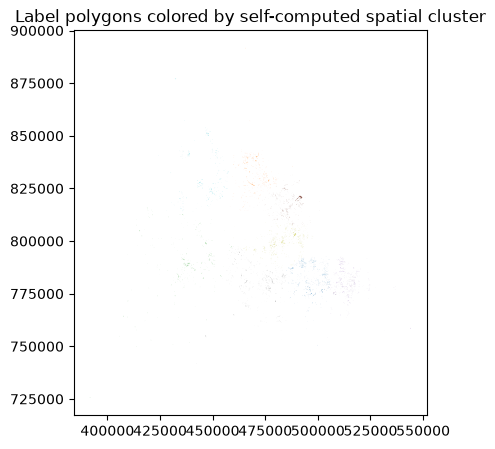

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))
labels.plot(column="cluster", cmap="tab10", ax=ax, legend=False)
ax.set_title("Label polygons colored by self-computed spatial cluster")
ax.set_aspect("equal")
plt.show()

In [17]:
def buffered_cluster_folds(gdf, cluster_col="cluster", buffer_m=500):
    """Yield (test_cluster_id, train_idx, test_idx) holding out one whole
    cluster at a time, with any train polygon within buffer_m of the test
    cluster's geometry excluded — strips cross-boundary spatial
    autocorrelation that plain block CV would still leak (Tobler's First
    Law). No random-fold option exists in this API: random k-fold is
    rejected by omission, not by a runtime check.
    """
    for test_cluster in sorted(gdf[cluster_col].unique()):
        test_mask = gdf[cluster_col] == test_cluster
        test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)
        train_mask = (~test_mask) & (~gdf.geometry.intersects(test_geom))
        yield test_cluster, gdf.index[train_mask].to_numpy(), gdf.index[test_mask].to_numpy()


for _test_cluster, _train_idx, _test_idx in buffered_cluster_folds(labels, buffer_m=500):
    assert not set(_train_idx) & set(_test_idx)
    _test_geom = labels.loc[_test_idx, "geometry"].unary_union.buffer(500)
    assert not labels.loc[_train_idx, "geometry"].intersects(_test_geom).any()
print(f"{labels['cluster'].nunique()} clusters -> {labels['cluster'].nunique()} buffered folds, all leakage-checked")

C:\Users\hasha\AppData\Local\Temp\ipykernel_21660\3534024352.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)


C:\Users\hasha\AppData\Local\Temp\ipykernel_21660\3534024352.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  _test_geom = labels.loc[_test_idx, "geometry"].unary_union.buffer(500)


C:\Users\hasha\AppData\Local\Temp\ipykernel_21660\3534024352.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)


C:\Users\hasha\AppData\Local\Temp\ipykernel_21660\3534024352.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  _test_geom = labels.loc[_test_idx, "geometry"].unary_union.buffer(500)


C:\Users\hasha\AppData\Local\Temp\ipykernel_21660\3534024352.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)


...

C:\Users\hasha\AppData\Local\Temp\ipykernel_21660\3534024352.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)


C:\Users\hasha\AppData\Local\Temp\ipykernel_21660\3534024352.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  _test_geom = labels.loc[_test_idx, "geometry"].unary_union.buffer(500)


C:\Users\hasha\AppData\Local\Temp\ipykernel_21660\3534024352.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  test_geom = gdf.loc[test_mask, "geometry"].unary_union.buffer(buffer_m)


C:\Users\hasha\AppData\Local\Temp\ipykernel_21660\3534024352.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  _test_geom = labels.loc[_test_idx, "geometry"].unary_union.buffer(500)


8 clusters -> 8 buffered folds, all leakage-checked


In [18]:
def positive_patch_window(centroid_xy, transform, size=256):
    """Pixel window centered on a polygon's centroid (world coords), for
    positive-sample extraction from pre-event imagery. Generic grid tiling
    (Step 2's iter_patches) isn't used for positives — they must be centered
    on the label, not wherever a fixed grid happens to land. Caller must
    clip the returned window against the raster's actual bounds before
    reading; that's not handled here.
    """
    col, row = ~transform * centroid_xy
    half = size // 2
    return Window(int(col) - half, int(row) - half, size, size)


_transform = from_origin(0, 1000, 10, 10)  # 10m pixels, origin at (0, 1000)
_win = positive_patch_window((500, 500), _transform, size=256)
assert (_win.col_off, _win.row_off) == (50 - 128, 50 - 128)

In [19]:
def slope_stratified_negative_candidates(dem, transform, resolution_m, positive_slopes_deg,
                                          exclusion_geom, bins=5, n_per_bin=20, rng=None):
    """Candidate (row, col) pixel locations for negatives, stratified to
    match the positive polygons' slope distribution, and excluded from
    within `exclusion_geom` (a buffered union of all positive polygons,
    e.g. 30-50m per the project plan) — see docs/limitations.md.
    """
    rng = rng or np.random.default_rng(0)
    slope, _ = slope_aspect(dem, resolution_m)
    edges = np.histogram_bin_edges(positive_slopes_deg, bins=bins)

    candidates = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        rows, cols = np.where((slope >= lo) & (slope < hi))
        if len(rows) == 0:
            continue
        pick = rng.choice(len(rows), size=min(n_per_bin, len(rows)), replace=False)
        candidates.extend(zip(rows[pick], cols[pick]))

    xs, ys = rasterio.transform.xy(transform, [r for r, c in candidates], [c for r, c in candidates])
    points = gpd.GeoSeries([Point(x, y) for x, y in zip(xs, ys)], crs=METRIC_CRS)
    keep = ~points.within(exclusion_geom)
    return [rc for rc, k in zip(candidates, keep) if k]


_dem = np.fromfunction(lambda r, c: c * 2.0, (50, 50))  # gentle east-facing ramp
_transform2 = from_origin(0, 500, 10, 10)
_positive_slopes = np.array([5.0, 8.0, 12.0])
_exclusion = box(-10, 390, 510, 510)  # excludes rows 0-11 (all columns)
_candidates = slope_stratified_negative_candidates(
    _dem, _transform2, 10, _positive_slopes, _exclusion, bins=3, n_per_bin=10, rng=np.random.default_rng(1)
)
assert len(_candidates) > 0
assert all(r >= 12 for r, c in _candidates)

In [20]:
def manifest_row(patch_id, product_id, sensing_date, cluster, is_positive):
    """One row of the provenance manifest — the audit trail that makes
    'pre-event-only' compliance independently checkable rather than assumed
    (see docs/limitations.md). Written to data/processed/manifest.csv once
    this runs against real downloaded imagery.
    """
    assert date.fromisoformat(sensing_date) < date.fromisoformat("2025-11-28"), (
        f"patch {patch_id}: sensing_date {sensing_date} is not strictly pre-event"
    )
    return {"patch_id": patch_id, "product_id": product_id, "sensing_date": sensing_date,
            "cluster": cluster, "is_positive": is_positive}


manifest_row("p0001", "S2B_MSIL2A_20250801T...", "2025-08-01", cluster=3, is_positive=True)

_rejected = False
try:
    manifest_row("bad", "x", "2025-12-01", cluster=0, is_positive=False)
except AssertionError:
    _rejected = True
assert _rejected, "should have rejected a post-event date"

## Status

Steps 1-3 implemented, with every non-trivial function checked against synthetic data above (no network/credentials needed for those checks). Not yet run against the real ACCIMT shapefile or downloaded Sentinel-2/DEM rasters end-to-end — to do that:

1. Copy the shapefile into `DATA_DIR/raw/labels/` (see `data/README.md`).
2. Set CDSE credentials (Colab Secrets, or a local `.env`).
3. Run Step 2's download cells, then re-run Step 1's label cell and Step 3's clustering/negative-sampling cells against the real files.

Not implemented yet (future milestones, not this notebook): modeling (U-Net/DeepLabV3+ + Focal-Dice loss), evaluation, write-up.